# Customer Risk Intelligence: A Churn Prediction and Retention Prioritization Framework

# DESCRIPTION

Customer churn poses a significant challenge for businesses, as retaining existing customers is often more cost-effective than acquiring new ones. This project develops a data-driven approach to identify customers at risk of churning and prioritize retention efforts based on their business value.

Using transactional retail data, customer behavior is first analyzed through RFM (Recency, Frequency, Monetary) analysis to understand purchasing patterns. A Customer Value Score (CVS) is then constructed to estimate the relative importance of each customer to the business.

To predict churn risk, a Random Forest classifier is trained using behavioral features such as purchase frequency, total spending, and average order value. Recency-based features are intentionally excluded from the model to avoid data leakage, as churn is defined using a recency threshold.

The model achieves ~70% test accuracy and a ROC-AUC score of ~0.73, indicating moderate predictive capability in identifying churn-risk customers based on behavioral patterns.

Beyond prediction, the project focuses on actionable business insights by combining churn probability with customer value to identify high-value customers at high risk of churn. These customers represent priority targets for retention campaigns.

**The final output of this analysis includes**:

A churn prediction model based on customer behavior

Feature importance analysis to identify drivers of churn

Risk–value segmentation of customers

Identification of the top 20% highest-risk customers

A revenue-at-risk analysis to estimate potential financial exposure

This framework demonstrates how machine learning can be integrated with customer analytics to support data-driven retention strategies and revenue protection.

#How This Project Differs from Conventional Churn Models

**Beyond prediction accuracy**: Most churn projects focus only on predicting churn, while this project links churn probability with customer value to prioritize retention decisions.

**Business-first framework**: Instead of treating churn purely as a classification problem, the analysis identifies high-value customers at high risk, enabling targeted retention strategies.

**Revenue impact estimation**: The model output is combined with customer spending data to estimate revenue exposure from high-risk customers, connecting machine learning results to real business outcomes.

# KEY FINDINGS

1.Customer spending behavior is the strongest predictor of churn risk.

2.The Random Forest model achieved ~70% accuracy and 0.73 ROC-AUC while avoiding recency-based data leakage.

3.The model correctly identifies ~74% of churn-risk customers.

4.The top 20% highest-risk customers represent a significant share of revenue exposure, indicating that targeted retention campaigns should prioritize this segment.

# PROJECT PIPELINE

Transaction Data

Customer Behavior Modeling (RFM)
       
Customer Value Scoring
       
Risk–Value Segmentation
       
Random Forest Churn Prediction
       
Feature Importance & Business Insights

Revenue at risk

Retention strategy

In [ ]:
import pandas as pd


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path="/content/drive/MyDrive/online_retail_II.xlsx"


df1=pd.read_excel(file_path,sheet_name='Year 2009-2010')
df2=pd.read_excel(file_path, sheet_name='Year 2010-2011')
df=pd.concat([df1,df2])


In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [ ]:
df.shape

(1067371, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067371 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 73.3+ MB


In [ ]:
df.head(100)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
95,489441,22111,SCOTTIE DOG HOT WATER BOTTLE,48,2009-12-01 09:44:00,4.25,18087.0,United Kingdom
96,489442,21955,UNION JACK GUNS & ROSES DOORMAT,2,2009-12-01 09:46:00,6.75,13635.0,United Kingdom
97,489442,22111,SCOTTIE DOG HOT WATER BOTTLE,3,2009-12-01 09:46:00,4.95,13635.0,United Kingdom
98,489442,22296,HEART IVORY TRELLIS LARGE,12,2009-12-01 09:46:00,1.65,13635.0,United Kingdom


In [ ]:
#finding the extent of null values in the dataset

df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [ ]:
type(df) #dataframe overwritten

pandas.core.frame.DataFrame

In [ ]:
df=df.dropna() #remove missing cutomerid and descriptions

In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [ ]:
#convert datatypes into into
df['Customer ID']=df['Customer ID'].astype(int)

/tmp/ipykernel_478/1331038864.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Customer ID']=df['Customer ID'].astype(int)


In [ ]:
#remove orders that were cancelled

df=df[~df['Invoice'].astype(str).str.startswith('C')]

In [ ]:
#removing negative values

df=df[(df['Quantity']>0) & (df['Price']>0)]

In [ ]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

#without datetime frequency and recency cannot be calculated

In [ ]:
#create total purchase work

df['Total Purchase']=df['Quantity']*df['Price']

In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Total Purchase
count,805549.000000,805549,805549.000000,805549.000000,805549.000000
mean,13.290522,2011-01-02 10:24:44.106814464,3.206561,15331.954970,22.026505
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-07 12:08:00,1.250000,13982.000000,4.950000
50%,5.000000,2010-12-03 15:10:00,1.950000,15271.000000,11.850000
75%,12.000000,2011-07-28 13:05:00,3.750000,16805.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,143.634088,NaN,29.199173,1696.737039,224.041928


In [ ]:
#max quantity and max price are outliers

In [ ]:
from os.path import exists
import os

os.makedirs('/content/drive/MyDrive/churn_project', exist_ok=True)
df.to_pickle('/content/drive/MyDrive/churn_project/cleaned.pkl')

In [ ]:
df = pd.read_pickle('/content/drive/MyDrive/churn_project/cleaned.pkl')

In [ ]:
#RFM Analysis

#creating a snapshot date (reference date)

snapshot_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)

In [ ]:
#creating an RFM frame

rfm=df.groupby('Customer ID').agg({

    "InvoiceDate": lambda x: (snapshot_date-x.max()).days,
    "Invoice":'nunique',
    "Total Purchase":'sum'
})

#renaming the columns

rfm.columns=["Recency", "Frequency","Monetary Value"]

In [ ]:
rfm.head(100)

,Recency,Frequency,Monetary Value
Customer ID,,,
12346,326,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40
...,...,...,...
12442,3,1,172.06
12443,732,1,485.31
12444,21,5,5005.46


In [ ]:
rfm.shape

(5878, 3)

In [ ]:
#Data has been transformed successfully

In [ ]:
rfm.describe()


#params: frequenc>0, min and max days make sense, all positive MValues

,Recency,Frequency,Monetary Value
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


In [ ]:
#rfm checkpoint

rfm.to_pickle('/content/drive/MyDrive/churn_project/rfm.pkl')

In [ ]:
print((rfm['Frequency']==1).mean())


#Observations:
#from the data description, the min values are too low for each case
#27% of customers never return after buying from this store once, thats 1/4 customers
#the store is good at acquiring customers but very bad at retaining them, maybe due to their limited products or high prices (Due to the min monetary value being low)

0.27611432460020413


In [ ]:
#Churning logic
# not purchased anything > 90 days= churned


rfm["Churn"]=(rfm['Frequency']>120).astype(int)

print(rfm['Churn'].value_counts())

Churn
0    5865
1      13
Name: count, dtype: int64


In [ ]:
#normalize frequency and recency

rfm['Frequency_norm']=(rfm["Frequency"]/rfm["Frequency"].max())

rfm["Recency_norm"]=(1-rfm["Recency"]/rfm["Recency"].max()) #inverting recency so that high score=high engagement


In [ ]:
rfm['Frequency_norm'].head()


,Frequency_norm
Customer ID,
12346,0.030151
12347,0.020101
12348,0.012563
12349,0.010050
12350,0.002513


In [ ]:
rfm['Recency_norm'].head()

,Recency_norm
Customer ID,
12346,0.558863
12347,0.997294
12348,0.898512
12349,0.974290
12350,0.580514


In [ ]:
# Engagement score logic

rfm['Engagement Score']= (0.6* rfm["Frequency_norm"]+ 0.4*rfm['Recency_norm'])


In [ ]:
rfm['Engagement Score'].head()

,Engagement Score
Customer ID,
12346,0.241636
12347,0.410978
12348,0.366942
12349,0.395746
12350,0.233713


In [ ]:
# Customer Value score (CVS)

rfm['CVS']=rfm['Monetary Value']*rfm['Engagement Score']

In [ ]:
rfm["CVS"].head()

,CVS
Customer ID,
12346,18740.416000
12347,2315.169221
12348,741.003259
12349,1752.636277
12350,78.153701


In [ ]:
# 0: customer not churned; active
# 1 :customer churned; churned

In [ ]:
rfm['Recency'].describe()

,Recency
count,5878.000000
mean,201.331916
std,209.338707
min,1.000000
25%,26.000000
50%,96.000000
75%,380.000000
max,739.000000


In [ ]:
rfm.sort_values("Recency", ascending=False).head()

,Recency,Frequency,Monetary Value,Churn,Frequency_norm,Recency_norm,Engagement Score,CVS
Customer ID,,,,,,,,
12636,739,1,141.00,0,0.002513,0.000000,0.001508,0.212563
17592,739,1,148.30,0,0.002513,0.000000,0.001508,0.223568
13526,738,2,1182.00,0,0.005025,0.001353,0.003556,4.203603
17818,738,1,130.18,0,0.002513,0.001353,0.002049,0.266714
15833,738,1,80.40,0,0.002513,0.001353,0.002049,0.164724


In [ ]:
(rfm["Recency"] > 120).mean()

np.float64(0.46903708744470907)

In [ ]:
rfm["Churn"] = (rfm["Recency"] > 120).astype(int)

rfm["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.530963
1,0.469037


In [ ]:
rfm["Frequency_norm"] = rfm["Frequency"] / rfm["Frequency"].max()

rfm["Recency_norm"] = 1 - (rfm["Recency"] / rfm["Recency"].max())

In [ ]:
rfm["Frequency_norm"].head()

,Frequency_norm
Customer ID,
12346,0.030151
12347,0.020101
12348,0.012563
12349,0.010050
12350,0.002513


In [ ]:
print(rfm["CVS"].describe())




count      5878.000000
mean       1297.890529
std        9146.129068
min           0.029995
25%          77.746983
50%         261.236673
75%         807.745118
max      376283.251417
Name: CVS, dtype: float64


In [ ]:
print(rfm['Engagement Score'].describe())

count    5878.000000
mean        0.300506
std         0.119858
min         0.001508
25%         0.198531
50%         0.355499
75%         0.394631
max         0.999459
Name: Engagement Score, dtype: float64


In [ ]:
rfm.shape

(5878, 8)

In [ ]:
rfm.to_pickle(
    '/content/drive/MyDrive/churn_project/rfm_final.pkl'
)

In [ ]:
df=pd.read_pickle('/content/drive/MyDrive/churn_project/rfm_final.pkl')

In [ ]:
df.head()

,Recency,Frequency,Monetary Value,Churn,Frequency_norm,Recency_norm,Engagement Score,CVS
Customer ID,,,,,,,,
12346,326,12,77556.46,1,0.030151,0.558863,0.241636,18740.416000
12347,2,8,5633.32,0,0.020101,0.997294,0.410978,2315.169221
12348,75,5,2019.40,0,0.012563,0.898512,0.366942,741.003259
12349,19,4,4428.69,0,0.010050,0.974290,0.395746,1752.636277
12350,310,1,334.40,1,0.002513,0.580514,0.233713,78.153701


In [ ]:
# RISK VS STRATEGY MATRIX


#Creating value matrix


rfm['ValueSegment']=pd.qcut(

      rfm['CVS'], q=3, labels=['Low Value', 'Medium Value', 'High Value']

)

In [ ]:
# creating risk segments

rfm['RiskSegment']=rfm['Churn'].map({0: 'Low Risk', 1:'High Risk'})

In [ ]:
#create the matrix

strategy_matrix=pd.crosstab(
    rfm['ValueSegment'],

    rfm['RiskSegment']


)
print(strategy_matrix)

RiskSegment   High Risk  Low Risk
ValueSegment                     
Low Value          1623       336
Medium Value        871      1088
High Value          263      1697


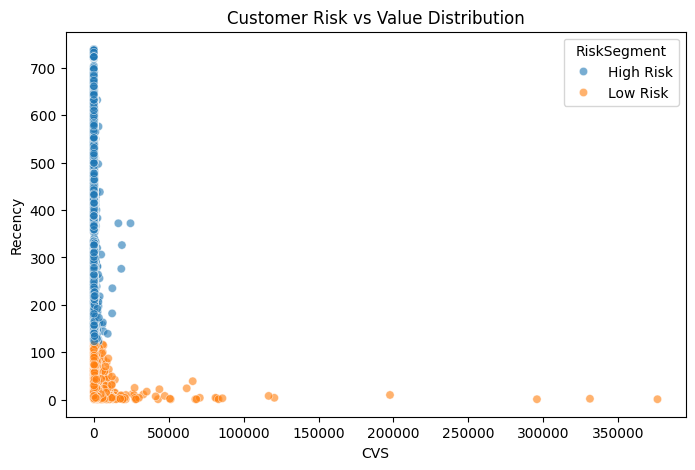

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="CVS",
    y="Recency",
    hue="RiskSegment",
    data=rfm,
    alpha=0.6
)

plt.title("Customer Risk vs Value Distribution")
plt.show()

In [ ]:
rfm.groupby("ValueSegment")["Churn"].mean() *100


#churn rate across segments vvimp

/tmp/ipykernel_478/2679933931.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm.groupby("ValueSegment")["Churn"].mean() *100


,Churn
ValueSegment,
Low Value,82.848392
Medium Value,44.461460
High Value,13.418367


In [ ]:
# Observations:
#low value customers leave early as compared to high value customers
#The bussiness is doing fine by that metric, so it is a retention problem??

In [ ]:
# 27% customers were likely to churn faster, those people might fall into this category of low val+high churn; The hypothesis was correct

In [ ]:
rfm.to_pickle('/content/drive/MyDrive/churn_project/rfm_strategy_ready.pkl')

In [ ]:
df=pd.read_pickle('/content/drive/MyDrive/churn_project/rfm_strategy_ready.pkl')

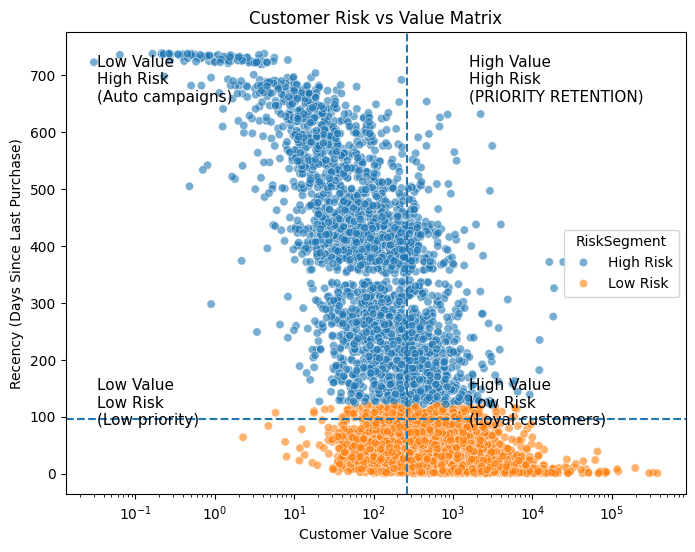

In [ ]:
#vizualization

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="CVS",
    y="Recency",
    hue="RiskSegment",
    alpha=0.6
)

value_median=rfm["CVS"].median()
recency_median=rfm["Recency"].median()


plt.xscale('log')
plt.axvline(value_median, linestyle="--")
plt.axhline(recency_median, linestyle="--")





#labelling the quadrants

# quadrant labels (axis-relative positions)

plt.text(0.05, 0.85,
         "Low Value\nHigh Risk\n(Auto campaigns)",
         transform=plt.gca().transAxes,
         fontsize=11)

plt.text(0.65, 0.85,
         "High Value\nHigh Risk\n(PRIORITY RETENTION)",
         transform=plt.gca().transAxes,
         fontsize=11)

plt.text(0.05, 0.15,
         "Low Value\nLow Risk\n(Low priority)",
         transform=plt.gca().transAxes,
         fontsize=11)

plt.text(0.65, 0.15,
         "High Value\nLow Risk\n(Loyal customers)",
         transform=plt.gca().transAxes,
         fontsize=11)

plt.title("Customer Risk vs Value Matrix")
plt.xlabel("Customer Value Score")
plt.ylabel("Recency (Days Since Last Purchase)")

plt.show()


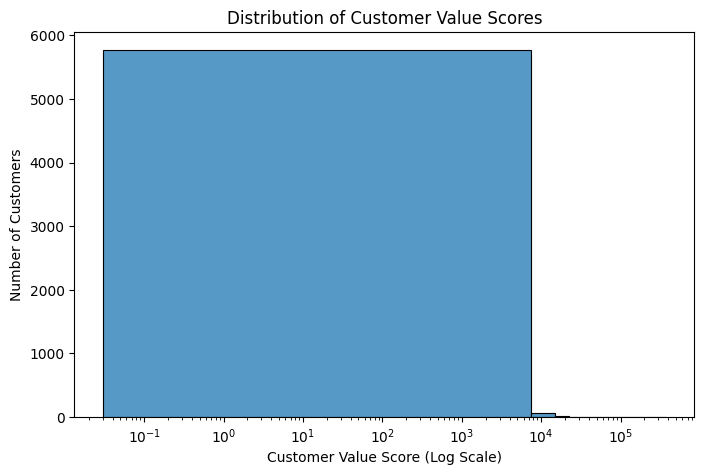

In [ ]:
#customer value distribution plot
#Proof of the 80/20 rule being applicable in this case

plt.figure(figsize=(8,5))

sns.histplot(rfm["CVS"], bins=50)

plt.xscale("log")

plt.title("Distribution of Customer Value Scores")
plt.xlabel("Customer Value Score (Log Scale)")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
rfm['AvgOrderval']=rfm['Monetary Value']/rfm['Frequency']

In [ ]:
# ML part

#features on which we base our models
X=rfm[['Frequency','Monetary Value','AvgOrderval']]
y=rfm['Churn']

In [ ]:

#test train split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# training a random forest model to make predictions

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model=RandomForestClassifier(n_estimators=1500, max_depth=18,min_samples_split=10,min_samples_leaf=3,max_features="sqrt", random_state=42)

rf_model.fit(X_train,y_train)





RandomForestClassifier(max_depth=18, min_samples_leaf=3, min_samples_split=10,
                       n_estimators=1500, random_state=42)

In [ ]:
#make predictions
y_predict=rf_model.predict(X_test)

In [ ]:
y_predict

array([1, 0, 1, ..., 1, 0, 1])

In [ ]:
accuracy=accuracy_score(y_test,y_predict)
print(accuracy)




0.6938775510204082


In [ ]:
#cross validation

from sklearn.model_selection import cross_val_score

cross_val_scores=cross_val_score(rf_model,X,y,cv=5)
print("CV Scores:", cross_val_scores)
print("Average CV Accuracy:", cross_val_scores.mean())

CV Scores: [0.67602041 0.67687075 0.68452381 0.66212766 0.67659574]
Average CV Accuracy: 0.6752276740483427


In [ ]:
#checking for overfitting

train_accuracy=rf_model.score(X_train,y_train)
test_accuracy=rf_model.score(X_test,y_test)


In [ ]:
print(train_accuracy)
print(test_accuracy)

0.8092301148447469
0.6938775510204082


In [ ]:
#Precision: How often the churn predictions are correct
#recall: How many churners were correctly identified by the model



In [ ]:
#classification report

from sklearn.metrics import classification_report

print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.75      0.66      0.70       634
           1       0.65      0.74      0.69       542

    accuracy                           0.69      1176
   macro avg       0.70      0.70      0.69      1176
weighted avg       0.70      0.69      0.69      1176



In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_predict)

array([[416, 218],
       [142, 400]])

In [ ]:
#ROC AUC: How well the model is able to tell the difference between churners vs non churners

from sklearn.metrics import roc_auc_score
y_prob = rf_model.predict_proba(X_test)[:,1]
roc_auc=roc_auc_score(y_test,y_prob)

print("ROC_AUC score:" ,roc_auc)

ROC_AUC score: 0.7337527791681703


In [ ]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Monetary Value    0.445130
AvgOrderval       0.308558
Frequency         0.246312
dtype: float64


In [ ]:
#Spending behavior (total spend and order value) is a stronger predictor of churn than purchase frequency
# suggesting that customer value signals are key indicators of long-term retention.

In [ ]:
# Post model step; Finding out which customers are worth chasing

In [ ]:
rfm['churn_prob']=rf_model.predict_proba(X)[:,1]

In [ ]:
rfm_sorted = rfm.sort_values("churn_prob", ascending=False)

In [ ]:
rfm_sorted

,Recency,Frequency,Monetary Value,Churn,Frequency_norm,Recency_norm,Engagement Score,CVS,ValueSegment,RiskSegment,AvgOrderval,churn_prob
Customer ID,,,,,,,,,,,,
15375,690,1,60.96,1,0.002513,0.066306,0.028030,1.708701,Low Value,High Risk,60.960000,0.990157
13818,430,1,61.28,1,0.002513,0.418133,0.168761,10.341648,Low Value,High Risk,61.280000,0.990157
16605,724,1,60.48,1,0.002513,0.020298,0.009627,0.582218,Low Value,High Risk,60.480000,0.989974
17174,218,1,59.90,1,0.002513,0.705007,0.283510,16.982264,Low Value,High Risk,59.900000,0.989841
15250,641,1,60.00,1,0.002513,0.132612,0.054552,3.273132,Low Value,High Risk,60.000000,0.989841
...,...,...,...,...,...,...,...,...,...,...,...,...
15465,20,32,12655.65,0,0.080402,0.972936,0.437416,5535.780842,High Value,Low Risk,395.489062,0.001147
13769,2,20,5800.42,0,0.050251,0.997294,0.429068,2488.775825,High Value,Low Risk,290.021000,0.001022
18075,23,20,5783.29,0,0.050251,0.968877,0.417701,2415.688896,High Value,Low Risk,289.164500,0.001022


In [ ]:
#Customer Ranks

rfm_sorted[[ 'churn_prob']].head()


,churn_prob
Customer ID,
15375,0.990157
13818,0.990157
16605,0.989974
17174,0.989841
15250,0.989841


In [ ]:
#finding out the top 20% in terms of risk

top_risk=rfm.sort_values("churn_prob", ascending=False).head(int(0.2*len(rfm)))

In [ ]:
top_risk

,Recency,Frequency,Monetary Value,Churn,Frequency_norm,Recency_norm,Engagement Score,CVS,ValueSegment,RiskSegment,AvgOrderval,churn_prob
Customer ID,,,,,,,,,,,,
15375,690,1,60.96,1,0.002513,0.066306,0.028030,1.708701,Low Value,High Risk,60.96,0.990157
13818,430,1,61.28,1,0.002513,0.418133,0.168761,10.341648,Low Value,High Risk,61.28,0.990157
16605,724,1,60.48,1,0.002513,0.020298,0.009627,0.582218,Low Value,High Risk,60.48,0.989974
17174,218,1,59.90,1,0.002513,0.705007,0.283510,16.982264,Low Value,High Risk,59.90,0.989841
15250,641,1,60.00,1,0.002513,0.132612,0.054552,3.273132,Low Value,High Risk,60.00,0.989841
...,...,...,...,...,...,...,...,...,...,...,...,...
17831,33,1,35.40,0,0.002513,0.955345,0.383646,13.581053,Low Value,Low Risk,35.40,0.771965
15087,282,1,306.94,1,0.002513,0.618403,0.248869,76.387801,Low Value,High Risk,306.94,0.771546
12918,626,1,10953.50,1,0.002513,0.152909,0.062671,686.469783,High Value,High Risk,10953.50,0.771415


In [ ]:
#filtering the high value customers from the top 20%

vip_risk_customers = top_risk[top_risk["ValueSegment"] == "High Value"
]

In [ ]:
print(vip_risk_customers.head())
print("No of At risk customers:",len(vip_risk_customers))

             Recency  Frequency  Monetary Value  Churn  Frequency_norm  \
Customer ID                                                              
16214            171          4         2038.25      1         0.01005   
15384            170          4         2027.79      1         0.01005   
17337            151          4         2027.87      1         0.01005   
12586             17          4         2062.67      0         0.01005   
12418            113          4         2021.20      0         0.01005   

             Recency_norm  Engagement Score         CVS ValueSegment  \
Customer ID                                                            
16214            0.768606          0.313473  638.935610   High Value   
15384            0.769959          0.314014  636.754272   High Value   
17337            0.795670          0.324298  657.634348   High Value   
12586            0.976996          0.396829  818.526298   High Value   
12418            0.847091          0.344866  697.

In [ ]:
#revenue at risk

vip_revenue=vip_risk_customers['Monetary Value'].sum()
print("Revenue at risk:", vip_revenue)

Revenue at risk: 80294.421


In [ ]:
#which customers to target first

print("Target the customers in the following order")

vip_risk_customers = vip_risk_customers.sort_values(
    "churn_prob",
    ascending=False
)

vip_risk_customers

Target the customers in the following order


,Recency,Frequency,Monetary Value,Churn,Frequency_norm,Recency_norm,Engagement Score,CVS,ValueSegment,RiskSegment,AvgOrderval,churn_prob
Customer ID,,,,,,,,,,,,
16214,171,4,2038.250,1,0.010050,0.768606,0.313473,638.935610,High Value,High Risk,509.562500,0.956798
15384,170,4,2027.790,1,0.010050,0.769959,0.314014,636.754272,High Value,High Risk,506.947500,0.954402
17337,151,4,2027.870,1,0.010050,0.795670,0.324298,657.634348,High Value,High Risk,506.967500,0.954366
12586,17,4,2062.670,0,0.010050,0.976996,0.396829,818.526298,High Value,Low Risk,515.667500,0.948769
12418,113,4,2021.200,0,0.010050,0.847091,0.344866,697.044000,High Value,Low Risk,505.300000,0.932962
17152,195,4,2016.500,1,0.010050,0.736130,0.300482,605.922181,High Value,High Risk,504.125000,0.929805
14885,132,3,1598.120,1,0.007538,0.821380,0.333075,532.293356,High Value,High Risk,532.706667,0.928915
16054,145,4,2111.880,1,0.010050,0.803789,0.327546,691.737239,High Value,High Risk,527.970000,0.924441
16529,190,4,2012.000,1,0.010050,0.742896,0.303188,610.015207,High Value,High Risk,503.000000,0.919249


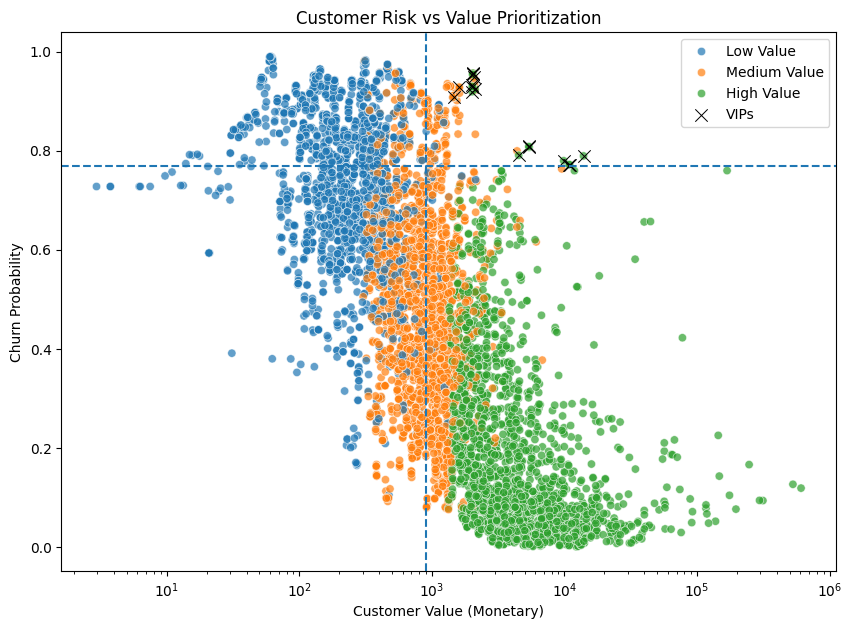

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=rfm,
    x="Monetary Value",
    y="churn_prob",
    hue="ValueSegment",
    alpha=0.7
)

#highlighting the vips

sns.scatterplot(

  data=vip_risk_customers,
  x="Monetary Value",
  y="churn_prob",
  color="black",
  marker="x",
  s=80,
  label="VIPs"
)
plt.xscale('log')
plt.axhline(rfm["churn_prob"].quantile(0.80), linestyle="--")
plt.axvline(rfm["Monetary Value"].median(), linestyle="--")

plt.xlabel("Customer Value (Monetary)")
plt.ylabel("Churn Probability")
plt.title("Customer Risk vs Value Prioritization")
plt.legend()
plt.show()

In [ ]:
#The black X shows high value high risk customers

Customers highlighted in black represent high-value customers with churn probability above the 80th percentile. These customers are priority targets for retention campaigns due to their high revenue contribution and elevated churn risk.

In [ ]:
#Revenue at risk calculations


rfm_sorted=rfm.sort_values("churn_prob", ascending=False)

rfm_sorted['cumulative_revenue']=rfm_sorted['Monetary Value'].cumsum()
rfm_sorted['customer_percentile']=(
    range(1,len(rfm_sorted)+1)

)
rfm_sorted['customer_percentile']=rfm_sorted['customer_percentile']/rfm_sorted['customer_percentile'].max()

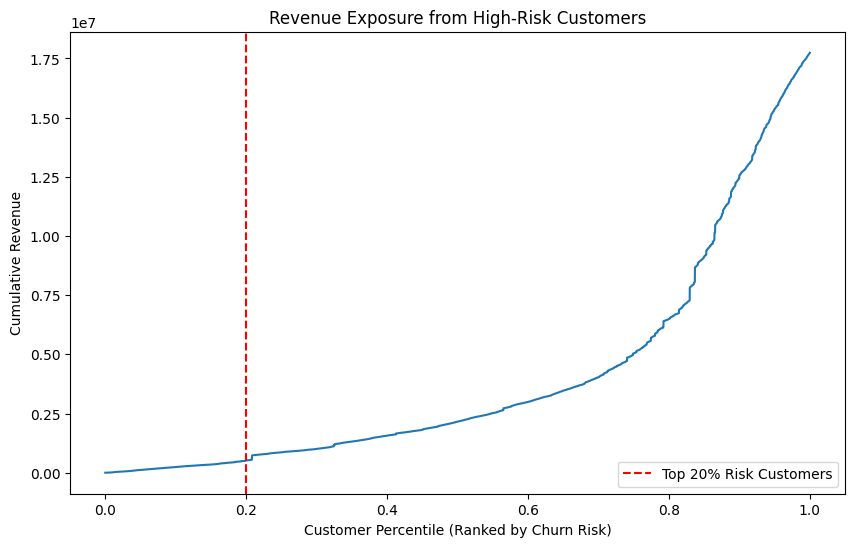

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    rfm_sorted["customer_percentile"],
    rfm_sorted["cumulative_revenue"]
)

plt.axvline(0.20, linestyle="--", color="red", label="Top 20% Risk Customers")

plt.xlabel("Customer Percentile (Ranked by Churn Risk)")
plt.ylabel("Cumulative Revenue")
plt.title("Revenue Exposure from High-Risk Customers")

plt.legend()
plt.show()

In [ ]:
top20 = rfm_sorted.head(int(0.2 * len(rfm_sorted)))

revenue_at_risk = top20["Monetary Value"].sum()
total_revenue = rfm["Monetary Value"].sum()

print("Revenue at Risk:", revenue_at_risk)
print("Share of Revenue:", revenue_at_risk / total_revenue)

Revenue at Risk: 522200.38200000004
Share of Revenue: 0.029430634673903625
